In [ ]:
from dotenv import load_dotenv
import os
load_dotenv('env')
AZURE_OPENAI_API_KEY = os.getenv('AZURE_OPENAI_API_KEY')
END_POINT=os.getenv('END_POINT')
MODEL_NAME=os.getenv('MODEL_NAME')
LANGSMITH_API_KEY=os.getenv('LANGSMITH_API_KEY')

AZURE_OPENAI_EMB_API_KEY = os.getenv('AZURE_OPENAI_EMB_API_KEY')
EMB_END_POINT=os.getenv('EMB_END_POINT')
EMB_MODEL_NAME=os.getenv('EMB_MODEL_NAME')

os.environ['LANGCHAIN_TRACING_V2'] = 'false'
os.environ['LANGCHAIN_PROJECT'] = 'LANG-1'

# 에이전트



In [12]:
from langchain.globals import set_debug
set_debug(False)

In [3]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,  
    azure_deployment=MODEL_NAME,          
    api_version="2024-12-01-preview",
    temperature=0.2,
)

prompt = ChatPromptTemplate.from_messages([
    ("system", "너는 간단한 계산기야. 사용자가 원하는 수식을 계산해서 값만 출력해."),
    ("user", "{input}"),
])

# llm(두뇌)과 도구, prompt(역할)을 연결하여 에이전트를 만든다. 
calc = prompt | llm | StrOutputParser()

print(calc.invoke({"input": "2와 3을 더하고, 거기에 3과 7을 곱한 값을 더해"}))

/anaconda/envs/azureml_py38/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(2 + 3) + (3 * 7) = 5 + 21 = 26


## 에이전트란?

- 목표를 달성하기 위해 **도구(툴)**를 선택·호출하고, 중간 결과를 바탕으로 스스로 다음 행동을 결정하는 실행 주체.

- LLM + Tool 사용: LLM이 “무엇을 할지”를 추론하고, 필요한 **외부 기능(검색, DB, API 호출 등)**을 툴로 실행.

- 복잡하고 복합적인 일들을 자동화하고 싶어서

에이전트를 구성하기 위해서는 다음과 같은 요소가 필요하다

- LLM: 에이전트의 지능을 담당. 예) ChatOpenAI

- 툴(Tool): 파이썬 함수에 스키마/설명 부여 → 이 도구는 어떤 것이고 어떻게 사용해야 하고 어떨 때 호출하는지 LLM이 알 수 있게 등록

- 에이전트(Policy): “언제 어떤 툴을 쓸지” 추론 (tool-calling / ReAct 등)
    - agent_scratchpad : 에이전트가 툴 호출 기록과 중간 사고과정을 담는 메모장을 쥐어줘야 한다.

- 실행기(AgentExecutor): 에이전트+툴+LLM을 묶어 실행

In [4]:
# pip install langchain langchain-openai
from langchain_openai import ChatOpenAI
from langchain.tools import tool
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

## 지능을 담당할 llm 모델
from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,  
    azure_deployment=MODEL_NAME,          
    api_version="2024-12-01-preview",
    temperature=0.2,
)

# tool은 특정 기능을 수행하는 데 함수로 정의할 수 있다. 
# tool 데코레이터를 통해 툴로 사용
@tool
def add(a: float, b: float) -> float:
    "두 실수(real number) a, b를 더한다."
    return a + b

@tool
def mul(a: float, b: float) -> float:
    "두 실수(real number) a, b를 곱한다."
    return a * b

# 에이전트가 사용할 툴의 목록 정의
tools = [add, mul]

# 에이전트의 역할 정의
prompt = ChatPromptTemplate.from_messages([
    ("system", "너는 간단한 계산기야. 주어진 도구를 호출해서 계산해."
    "출력은 결과 값만 간단하게 써"),
    ("user", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad")
])

# llm(두뇌)과 도구, prompt(역할)을 연결하여 에이전트를 만든다. 
agent = create_tool_calling_agent(llm, tools, prompt)

# 실행기
executor = AgentExecutor(agent=agent, tools=tools, verbose=True)



In [5]:
result = executor.invoke({"input": "2와 3을 더하고, 또 3과 7을 곱한 값을 더해"})
print(result)

print(result['output'][0]['text'])



> Entering new AgentExecutor chain...

Invoking: `add` with `{'a': 2, 'b': 3}`


5.0
Invoking: `mul` with `{'a': 3, 'b': 7}`


21.0
Invoking: `add` with `{'a': 5, 'b': 21}`


26.026

> Finished chain.
{'input': '2와 3을 더하고, 또 3과 7을 곱한 값을 더해', 'output': '26'}


In [7]:
from langchain.tools import tool
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.output_parsers import StrOutputParser

## 지능을 담당할 llm 모델
from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,  
    azure_deployment=MODEL_NAME,          
    api_version="2024-12-01-preview",
    temperature=0.2,
)

# tool은 특정 기능을 수행하는 데 함수로 정의할 수 있다. 
# tool 데코레이터를 통해 툴로 사용
@tool
def add(a: float, b: float) -> float:
    """두 실수(real number) a, b를 더한다."""
    return a + b

@tool
def mul(a: float, b: float) -> str:
    """두 실수(real number) a, b를 곱한다."""
    return a * b

@tool
def splitter(text:str) -> str:
    """복합적인 계산 문장이 들어왔을 때 두개의 계산 요구 문장으로 나눈다"""
    
    prompt =  ChatPromptTemplate.from_messages([
    ("system", "너는 복잡한 계산 문장을 작은 두개의 문장으로 나누는 도구야."
    "예를 들면 <a + b 와 c + d를 계산해줘>라는 문장이 있으면 <a + b>와 <c + d>라는 두개의 문장으로 나눌 수 있어."
    "출력은 두 문장의 리스트로 출력해"),
    ("user", "{input}"),
    ])

    return (prompt | llm | StrOutputParser()).invoke(text)


# 에이전트가 사용할 툴의 목록 정의
tools = [add, mul, splitter]

# 에이전트의 역할 정의
prompt = ChatPromptTemplate.from_messages([
    ("system", "너는 간단한 계산기야. 주어진 도구를 호출해서 계산해."
    "출력은 결과 값만 간단하게 써"),
    ("user", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad")
])

# llm(두뇌)과 도구, prompt(역할)을 연결하여 에이전트를 만든다. 
agent = create_tool_calling_agent(llm, tools, prompt)

# 실행기
executor = AgentExecutor(agent=agent, tools=tools, verbose=True)

result = executor.invoke({"input": "2와 3을 더하고, 또 3과 7을 곱한 값을 더해"})
print(result)

print(result['output'])



> Entering new AgentExecutor chain...

Invoking: `splitter` with `{'text': '2와 3을 더하고, 또 3과 7을 곱한 값을 더해'}`


["2와 3을 더해", "3과 7을 곱한 값을 더해"]
Invoking: `add` with `{'a': 2, 'b': 3}`


5.0
Invoking: `mul` with `{'a': 3, 'b': 7}`


21.0
Invoking: `add` with `{'a': 5, 'b': 21}`


26.026

> Finished chain.
{'input': '2와 3을 더하고, 또 3과 7을 곱한 값을 더해', 'output': '26'}
26


In [8]:
from langchain.globals import set_debug
set_debug(True)

result = executor.invoke({"input": "2와 3을 더하고, 거기에 3과 7을 곱한 값을 더해"})
print(result)


[chain/start] [chain:AgentExecutor] Entering Chain run with input:
{
  "input": "2와 3을 더하고, 거기에 3과 7을 곱한 값을 더해"
}
[chain/start] [chain:AgentExecutor > chain:RunnableSequence] Entering Chain run with input:
{
  "input": ""
}
[chain/start] [chain:AgentExecutor > chain:RunnableSequence > chain:RunnableAssign<agent_scratchpad>] Entering Chain run with input:
{
  "input": ""
}
[chain/start] [chain:AgentExecutor > chain:RunnableSequence > chain:RunnableAssign<agent_scratchpad> > chain:RunnableParallel<agent_scratchpad>] Entering Chain run with input:
{
  "input": ""
}
[chain/start] [chain:AgentExecutor > chain:RunnableSequence > chain:RunnableAssign<agent_scratchpad> > chain:RunnableParallel<agent_scratchpad> > chain:RunnableLambda] Entering Chain run with input:
{
  "input": ""
}
[chain/end] [chain:AgentExecutor > chain:RunnableSequence > chain:RunnableAssign<agent_scratchpad> > chain:RunnableParallel<agent_scratchpad> > chain:RunnableLambda] s] Exiting Chain run with output:
{
  "output": 

## Tool을 사용하는 에이전트 

https://python.langchain.com/docs/integrations/tools/

### 유투브 영상 검색

In [10]:
%pip install -q youtube-comment-downloader youtube-search

Note: you may need to restart the kernel to use updated packages.


In [13]:
from langchain_community.tools import YouTubeSearchTool

tool = YouTubeSearchTool(max_results=10)

result = tool.run("GenG 세대")
print(result)

['https://www.youtube.com/watch?v=5Fb0ZPTeC94&pp=ygULR2VuRyDshLjrjIA%3D', 'https://www.youtube.com/watch?v=CVo6CfDbgrQ&pp=ygULR2VuRyDshLjrjIA%3D']


### 논문 검색

In [14]:
%pip install arxiv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 6.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - \ | done
  Created wheel for sgmllib3k: filename=sgmllib3k-1.0.0-py3-none-any.whl size=6089 sha256=ea301312628e1e93a5b06278a76c8591fcbaca77d4aa64579e60ee8cdd922c0c
  Stored in directory: /home/azureuser/.cache/pip/wheels/3b/24/68/f82c1fe16fe6cc7c6f9f67fe4bbf2a4ce527dea6b14a4b34ee
Successfully built sgmllib3k
Note: you may need to restart the kernel to use updated packages.


In [15]:
from langchain_community.tools import ArxivQueryRun

arxiv = ArxivQueryRun()
result = arxiv.run("langchain")
print(result)

Published: 2025-01-27
Title: From Prompt Injections to SQL Injection Attacks: How Protected is Your LLM-Integrated Web Application?
Authors: Rodrigo Pedro, Daniel Castro, Paulo Carreira, Nuno Santos
Summary: Large Language Models (LLMs) have found widespread applications in various
domains, including web applications, where they facilitate human interaction
via chatbots with natural language interfaces. Internally, aided by an
LLM-integration middleware such as Langchain, user prompts are translated into
SQL queries used by the LLM to provide meaningful responses to users. However,
unsanitized user prompts can lead to SQL injection attacks, potentially
compromising the security of the database. Despite the growing interest in
prompt injection vulnerabilities targeting LLMs, the specific risks of
generating SQL injection attacks through prompt injections have not been
extensively studied. In this paper, we present a comprehensive examination of
prompt-to-SQL (P$_2$SQL) injections target

### 인터넷 검색

In [17]:
%pip install -q readability-lxml

Note: you may need to restart the kernel to use updated packages.


tavily를 쓰려면 키를 발급받아야 합니다.

[TAVILY 키 발급 링크](https://app.tavily.com/sign-in)

In [18]:
tavily_api_key = os.getenv('TAVILY_API_KEY')
print(tavily_api_key[:5])

tvly-


In [19]:
from langchain_community.tools.tavily_search import TavilySearchResults

search = TavilySearchResults(k=6, api_key = tavily_api_key)
result = search.invoke("GenG 세대는 무엇인가요?")
print(result)

/tmp/ipykernel_42785/1523909936.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-tavily package and should be used instead. To use it run `pip install -U :class:`~langchain-tavily` and import as `from :class:`~langchain_tavily import TavilySearch``.
  search = TavilySearchResults(k=6, api_key = tavily_api_key)


[{'title': 'Gen.G Esports - 나무위키', 'url': 'https://namu.wiki/w/Gen.G%20Esports', 'content': '창단 후 KSV Esports( "Korea Silicon Valley의 약자라고 한다. 장난식으로 각 게임 팬덤마다 불리는 약자가 다른데 롤은 King Super amVition, 강서방(Kang Seo Vang) 이라고 하고 히오스는 큰사발(Keun Sa Val), 코리안 쌍검 바리안(Korean Ssanggeom Varian), 코리아 섹시 뱅붕(Korea Sexy Vangbung), 김치소주불고기(Kimchi Soju Bulgogi) 등으로 불린다.")라는 이름을 사용하다 2018년 5월 4일 Gen.G Esports로 팀명을 리브랜딩했다. Gen.G는 Generation Gaming의 약자로, 게임 산업의 새로운 시대가 도래했고 우리가 그 시대의 표준이 되겠다는 의미를 담고 있다. 두 개의 G가 마주본 형상의 새로운 로고는 딜러(검), 탱커(방패), 서포터(하트)를 상징한다. [...] 서울 다이너스티 개인 테마곡이었던 pH-1의 82와는 달리 젠지 구단 자체를 대표하는 테마곡이 새로 생겼다. Junoflo - BOMB! \n\n   2020년 6월 9일 아시아 프로게임단 최초로 푸마 "푸마(브랜드)")와 다년간의 스폰서십을 맺었다#. \n\n   2020년 8월 긱스타와의 협업으로 신촌에 젠지 PC 카페를 오픈했다. 로그인 화면은 젠지 팀의 경력을 보여주는데, 히오스 팀의 경력도 붙어있다. \n\n   뉴스기사에 나오는 \'젠지\'는 e스포츠 기사가 아니면 보통 Z세대를 뜻하는 Gen.Z다. \n\n   전반적으로 타 팀에 비해 FPS 투자가 많은 편이지만 발로란트 팬덤에서는 T1과 함께 2022년 VCT 프랜차이즈 입성 과정에서 북미 탈락 후 아시아태평양권으로 들어온 문제로 인하여 좋지 못한 평을 받았으며, 프랜차이즈에 탈락한 Dplus KIA, Crazy Raccoon 팬들에게 원성

## Tool Calling 기반 최신 내용 검색기

In [21]:
# pip install langchain langchain-openai langchain-community readability-lxml beautifulsoup4 python-dotenv

import os, re
from typing import List
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain.agents import AgentExecutor, create_tool_calling_agent
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.tools import ArxivQueryRun

from langchain.tools import tool
from readability import Document
from bs4 import BeautifulSoup


web_search = TavilySearchResults(max_results=15)  
arxiv = ArxivQueryRun()                          

tools = [web_search, arxiv] #<-- 사용할 도구 2가지

SYSTEM = """너는 Agentic기반의 RAG 답변기야.
사용자의 질문에 답하기 위해 아래 도구들을 적절히 선택해 사용해.
사용자는 일반적인 질문 혹은 전문적인 이론에 대한 질문을 할 수 있어.

도구 사용 가이드:
- 최신/실무/일반 지식 → TavilySearchResults (웹)
- 학술/이론/정의/연구 동향 → ArxivQueryRun (논문)
- 검색 결과가 답변을 하기에 충분하지 않다면 질문을 개선해서 툴을 반복적으로 수행해

중지 조건:
- 질문에 답하기에 충분한 근거가 수집되었다고 판단될 때.
- 이미 수집한 결과와 동일하거나 유사한 결과가 계속 수집될 때
- 10번 이상 반복했을 때

출력 규칙:
- 본문은 한국어로 간결/정확
- 마지막 줄에 "출처:" 다음 줄에 사용한 URL 들을 개행으로 나열
- 출처가 없으면 답변하지 말고 추가 검색/열람을 수행

반드시 도구를 적절히 사용하고, 근거가 없으면 답변하지 말고 도구를 더 호출하라.
"""

prompt = ChatPromptTemplate.from_messages([
    ("system", SYSTEM),
    ("user", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"), #<-- tool을 쓸 때 중간 정보를 기록할 메모장
])

# ===== 4) LLM & Agent =====
from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,  
    azure_deployment=MODEL_NAME,          
    api_version="2024-12-01-preview",
    temperature=0.2,
)
agent = create_tool_calling_agent(llm, tools, prompt)

executor = AgentExecutor(
    agent=agent,
    tools=tools,
    verbose=False,          # 중간 툴 호출 로그를 콘솔에 출력, 개발이 완료되면 실제 서비스에서는 False
    max_iterations=6,      # 필요시 늘리기
    handle_parsing_errors=True,
)

In [22]:
q = "트랜스포머가 무엇인가요? 직관적으로 설명하고, 핵심 논문이나 좋은 소개 글 출처도 알려줘."
resp = executor.invoke({"input": q})
print("\n=== 최종 답변 ===\n")
print(resp["output"])

# https://poloclub.github.io/transformer-explainer/


=== 최종 답변 ===

트랜스포머(Transformer)는 자연어 처리 등 순차 데이터(sequence)를 다루는 데 혁신적인 신경망 모델입니다. 기존에는 순환 신경망(RNN)이나 LSTM 같은 구조가 주로 쓰였지만, 트랜스포머는 '어텐션(attention)' 메커니즘만으로 입력 시퀀스 내 모든 단어 간의 관계를 한꺼번에 파악할 수 있어 병렬 처리가 가능하고, 더 긴 문맥도 효과적으로 이해할 수 있습니다.

직관적으로 설명하면, 트랜스포머는 문장 내 각 단어가 다른 단어들과 얼마나 관련 있는지를 스스로 판단해 중요한 단어에 집중(attention)합니다. 예를 들어, 문장에서 'train'이라는 단어가 있을 때, 주변 단어들을 참고해 '기차'인지 '훈련하다'인지 의미를 구분하는 식입니다. 이 과정은 '쿼리(Query)', '키(Key)', '밸류(Value)'라는 벡터 변환을 통해 수학적으로 구현되며, 이로써 문맥을 반영한 단어 표현을 만듭니다.

트랜스포머는 인코더-디코더 구조를 가지며, 인코더는 입력 문장을 이해하고, 디코더는 이를 바탕으로 번역, 생성 등 원하는 출력을 만듭니다. 핵심은 '셀프 어텐션(self-attention)'으로, 입력 시퀀스 내 모든 위치의 단어들이 서로를 참조해 정보를 주고받습니다.

대표적인 핵심 논문은 2017년 구글에서 발표한 "Attention is All You Need"입니다. 이 논문에서 트랜스포머 구조와 어텐션 메커니즘이 처음 소개되어 이후 자연어 처리와 AI 분야에 큰 영향을 끼쳤습니다.

더 자세하고 직관적인 설명은 아래 출처들을 참고하면 좋습니다.

출처:
https://blog.paperspace.com/attention-is-all-you-need-the-components-of-the-transformer/
https://towardsdatascience.com/transformers-intuitively-and-exhaustively-explained-58a5c5df8dbb/
https://jala

In [23]:
q = "트랜스포머가 참 재미있었어. 전체 시리즈를 요약해줘"
resp = executor.invoke({"input": q})
print("\n=== 최종 답변 ===\n")
print(resp["output"])


=== 최종 답변 ===

트랜스포머 시리즈는 크게 애니메이션과 실사 영화 시리즈로 나뉘며, 1984년 첫 애니메이션 방영 이후 40여 년간 다양한 작품이 제작되었습니다.

1. 애니메이션 시리즈
- 1984년부터 1987년까지 방영된 최초의 《트랜스포머》 애니메이션은 차량 등으로 변신하는 거대 로봇들의 전쟁을 다룹니다.
- 1986년 극장판 《트랜스포머: 더 무비》가 제작되었고, 이후 여러 TV 시리즈와 애니메이션 영화가 이어졌습니다.
- 최근에는 2024년 개봉 예정인 애니메이션 영화 《트랜스포머: 원》이 프리퀄로, 옵티머스 프라임과 메가트론이 친구였다가 적이 되는 과정을 다룹니다.

2. 실사 영화 시리즈
- 2007년 마이클 베이 감독, 스티븐 스필버그 제작 참여로 시작된 실사 영화 시리즈는 총 5편이 제작되었습니다.
- 1편 《트랜스포머》(2007)는 그래픽과 연출 면에서 호평받았고, 전 세계적으로 큰 흥행 성공을 거두었습니다.
- 2편부터 5편까지는 스토리 전개와 캐릭터 비중 배분에서 호불호가 갈렸으며, 특히 3편부터 평론가들의 혹평이 많았습니다.
- 2018년에는 스핀오프 영화 《범블비》가 개봉했고, 2023년에는 《트랜스포머: 비스트의 서막》이 나왔습니다.

전체적으로 트랜스포머 시리즈는 오토봇과 디셉티콘 간의 전쟁과 인간과 로봇의 관계를 중심으로 다양한 이야기와 세계관을 확장해왔습니다. 실사 영화는 화려한 시각효과와 액션으로 인기를 끌었고, 애니메이션과 만화는 깊이 있는 세계관과 캐릭터 스토리를 제공합니다.

출처:
https://m.blog.naver.com/nyria99/223546515460
https://namu.wiki/w/%ED%8A%B8%EB%9E%9C%EC%8A%A4%ED%8F%AC%EB%A8%B8%20%EC%8B%9C%EB%A6%AC%EC%A6%88
https://ko.wikipedia.org/wiki/%ED%8A%B8%EB%9E%9C%EC%8A%A4%ED%8F%AC%EB%A8%B8_(%EC%95%A0%EB%8B%88%EB%A

In [24]:
q = "요즘 전세계에서 젊은 사람들에게서 인기있는 영화/드라마가 뭐야?"
resp = executor.invoke({"input": q})
print("\n=== 최종 답변 ===\n")
print(resp["output"])


=== 최종 답변 ===

2024년 전세계 젊은 층에게 인기 있는 영화와 드라마는 다음과 같습니다.

영화:
- Dune: Part Two
- Inside Out 2
- The Substance
- Fig (국제 영화로 호평)
- 다양한 장르의 영화들이 인기를 끌고 있음 (SF, 애니메이션, 공포 등)

드라마:
- K-드라마가 여전히 큰 인기를 누리고 있으며, 특히 'Lovely Runner' 같은 작품이 주목받음
- 미국, 영국 등지에서는 'Only Murders in the Building', 'Slow Horses' 같은 스파이/미스터리 장르가 인기
- 'Love Is Blind', 'Industry', 'My Lady Jane' 등 다양한 장르의 TV 시리즈도 젊은 층에게 호응을 얻음
- 넷플릭스, 디즈니+ 등 스트리밍 플랫폼에서 방영되는 신작들이 주목받음

특히 K-드라마는 전세계적으로 꾸준한 인기를 유지하고 있으며, 다양한 장르와 소재로 젊은 시청자들의 관심을 받고 있습니다.

출처:
https://www.imdb.com/list/ls590411493/
https://www.theguardian.com/tv-and-radio/2024/dec/09/the-50-best-tv-shows-of-2024
https://time.com/7201080/best-k-dramas-2024/
https://editorial.rottentomatoes.com/guide/best-2024-movies-every-certified-fresh/
https://www.teenvogue.com/story/best-tv-shows-2024-according-to-teen-vogue-staff
https://www.statista.com/statistics/999239/south-korea-korean-drama-popularity-worldwide/


## 그래프 기반 RAG

In [27]:
%pip install -q langchain langgraph langchain-openai langchain-community python-dotenv

Note: you may need to restart the kernel to use updated packages.


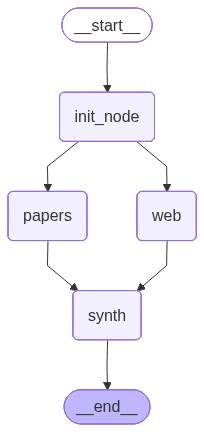

In [32]:

from typing import TypedDict, Annotated, List, Dict, Any, Optional
import operator, os
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.tools import ArxivQueryRun
from langchain_core.output_parsers import StrOutputParser

from langchain_openai import AzureChatOpenAI

llm = AzureChatOpenAI(
    api_key=AZURE_OPENAI_API_KEY,
    azure_endpoint=END_POINT,  
    azure_deployment=MODEL_NAME,          
    api_version="2024-12-01-preview",
    temperature=0.2,
)

# State 정의
class State(TypedDict):
    question: str
    web_results: Annotated[List[Dict[str, Any]], operator.add]     # Tavily 결과 누적
    paper_results: Annotated[List[str], operator.add]              # Arxiv 결과 누적
    answer: Optional[str]
    logs: Annotated[List[str], operator.add]

def init_node(state: State):

    return {"logs": [f"[init_node]"]}

# Tavily 웹 검색 노드 
tavily = TavilySearchResults(max_results=10)

def search_web(state: State):
    items = tavily.invoke({"query": state["question"]})

    # 제목과 주고, 내용만 추출
    simple = [{"title": it.get("title"), "url": it.get("url"), "snippet": it.get("snippet")} for it in items]
    return {"web_results": simple, "logs": [f"[tavily] {len(simple)} hits"]} # 결과를 web_result에 반환

# Arxiv 논문 검색 노드 
arxiv = ArxivQueryRun()  

def search_papers(state: State):
    text = arxiv.run(state["question"])  # 제목/저자/초록 요약이 문자열로 옴
    return {"paper_results": [text], "logs": [f"[arxiv] block_len={len(text)}"]} # 결과를 paper_results에 반환

# 통합 요약/답변 노드 <-- RAG 파트
synth_prompt = ChatPromptTemplate.from_messages([
    ("system",
     "너는 RAG 답변기야. 아래 웹 검색 결과와 논문 요약을 참고해, 질문에 대해 한국어로 정확하고 간결히 답해. "
     "최대한 웹과 논문에 사용자의 질문데 대한 대답이 있다면 해당 근거해서 대답해"
     "만약 검색한 내용이 질문을 답하기에 충분하지 않으면 함부로 추측하지 말고 네가 추천하는 더 좋은 질문을 사용자에게 제안해"
     "마지막에 출처 URL이 있으면 정리해서 출력해."),
    ("user", "질문: {q}\n\n[웹]\n{web}\n\n[논문]\n{papers}\n\n최종 답변:")
])

def synthesize(state: State):
    # 웹/논문 문자열로 합치기
    web_txt = "\n".join([f"- {w.get('title')} ({w.get('url')}) :: {w.get('snippet')}" for w in state.get("web_results", [])])
    paper_txt = "\n---\n".join(state.get("paper_results", []))[:10000]  # 길이가 너무 길면 앞 부분만 잘라서
    out = (synth_prompt | llm | StrOutputParser()).invoke({"q": state["question"], "web": web_txt, "papers": paper_txt})
    return {"answer": out, "logs": ["[synth] done"]}

# --- 그래프 구성 ---
graph = StateGraph(State)
graph.add_node("init_node", init_node)
graph.add_node("web", search_web)
graph.add_node("papers", search_papers)
graph.add_node("synth", synthesize)

graph.set_entry_point("init_node")

# 병렬 분기: query → (web, papers)
graph.add_edge("init_node", "web")
graph.add_edge("init_node", "papers")

# 두 경로가 끝나면 synth로 합류
graph.add_edge("web", "synth")
graph.add_edge("papers", "synth")
graph.add_edge("synth", END)

app = graph.compile()

# plot graph
from IPython.display import Image
Image(app.get_graph().draw_mermaid_png())

In [33]:
def run(q:str):

    # question: str
    # web_results: Annotated[List[Dict[str, Any]], operator.add]     
    # paper_results: Annotated[List[str], operator.add]            
    # answer: Optional[str]
    # logs: Annotated[List[str], operator.add]

    init_state = {'question':q, 'search_query':None, 'web_results':[], 'paper_results':[], 'answer':None, 'logs':[]}
    return app.invoke(init_state)['answer']

result = run('트랜스포머가 뭐야?')
print(result)

트랜스포머(Transformer)는 인공신경망의 한 종류로, 주로 자연어 처리 분야에서 사용되는 딥러닝 모델입니다. 기존의 순환 신경망(RNN)이나 합성곱 신경망(CNN)과 달리, 트랜스포머는 '어텐션 메커니즘(attention mechanism)'을 기반으로 하여 문장 내 단어들 간의 관계를 효과적으로 파악합니다. 이를 통해 병렬 처리가 가능해 학습 속도가 빠르고, 긴 문장이나 문맥도 잘 이해할 수 있습니다. 트랜스포머는 번역, 요약, 질의응답 등 다양한 자연어 처리 작업에서 혁신적인 성능을 보여 AI 혁명의 핵심 모델로 평가받고 있습니다.

출처:
- https://ko.wikipedia.org/wiki/%ED%8A%B8%EB%9E%9C%EC%8A%A4%ED%8F%AC%EB%A8%B8_(%EA%B8%B0%EA%B3%84_%ED%95%99%EC%8A%B5)
- https://blog.kakaocloud.com/91
- https://ai-inform.tistory.com/entry/%ED%8A%B8%EB%9E%9C%EC%8A%A4%ED%8F%AC%EB%A8%B8Transformer%EB%9E%80-%ED%8A%B8%EB%9E%9C%EC%8A%A4%ED%8F%AC%EB%A8%B8-%EC%89%AC%EC%9A%B4-%EC%84%A4%EB%AA%85


In [34]:
result = run('GenG세대가 뭐고 그 세대가 가장 좋아하는 요즘 트랜드가 뭐야?')
print(result)

GenG세대는 'Gen Z' 또는 'Z세대'라고도 불리며, 대략 1990년 중반부터 2010년 초반 사이에 태어난 세대를 의미합니다. 이 세대는 디지털 환경에서 자라난 첫 세대로, 인터넷과 스마트폰, 소셜 미디어가 일상에 깊숙이 자리 잡은 환경에서 성장했습니다.

GenG세대가 가장 좋아하는 요즘 트렌드는 다음과 같습니다:

1. **디지털 콘텐츠와 소셜 미디어**: 틱톡, 인스타그램, 유튜브 같은 플랫폼에서 짧고 임팩트 있는 영상 콘텐츠를 즐기며, 웬즈데이(Wednesday) 같은 드라마나 밈 문화에 열광합니다.

2. **개성 표현과 다양성 존중**: 자신만의 개성을 중시하고, 성별, 인종, 문화적 다양성을 존중하는 경향이 강합니다.

3. **친환경 및 윤리적 소비**: 환경 보호와 사회적 책임을 고려한 브랜드와 제품을 선호합니다.

4. **패션과 라이프스타일**: 스트리트 패션, 빈티지 스타일, 그리고 편안하면서도 개성 있는 스타일을 추구합니다.

5. **경험 중심 소비**: 물질적 소유보다는 경험과 감성을 중시하는 소비 패턴을 보입니다.

즉, GenG세대는 디지털 네이티브로서 빠른 정보 소비와 공유를 즐기며, 개성과 사회적 가치를 중시하는 트렌드를 선도하고 있습니다.

출처:  
- https://www.accio.com/business/ko/%EC%A0%A0%EC%A7%80%ED%8A%B8%EB%A0%8C%EB%93%9C  
- https://avocadogiant.com/newsletter/korea/2023-gen-z-%EB%A7%88%EC%BC%80%ED%8C%85-%ED%8A%B8%EB%A0%8C%EB%93%9C/  
- http://komipo-webzine.co.kr/page/vol26/06.html


In [35]:
result = run('이미지 생성 분야인 diffuion 모델의 최신 연구 동향은?')
print(result)

최신 이미지 생성 분야의 diffusion 모델 연구 동향은 다음과 같습니다.

1. **텍스트 기반 이미지-비디오 생성 (Text-driven Image to Video Generation)**  
   최근 연구에서는 diffusion 모델을 활용해 텍스트 설명과 첫 프레임 이미지를 입력받아 고품질의 제어 가능한 비디오를 생성하는 TIV-Diffusion 같은 프레임워크가 제안되고 있습니다. 이 모델은 객체 중심의 텍스트-비주얼 정렬(object-centric textual-visual alignment)을 통해 텍스트로 묘사된 객체와 그 움직임 경로를 정확히 인식하고, 객체별로 텍스트 특징을 개별 정렬하여 객체 소실이나 움직임 불일치 문제를 줄이는 데 주력합니다. 이를 통해 기존 방법 대비 더 높은 품질의 비디오 생성이 가능해졌습니다.

2. **객체 중심 제어 및 정렬**  
   객체 단위로 텍스트와 시각 정보를 융합하고 조절(scale-offset modulation)하여, 객체별 움직임과 위치를 세밀하게 제어하는 연구가 활발합니다. 이는 이미지 생성뿐 아니라 영상 생성까지 확산 모델의 적용 범위를 넓히는 중요한 발전입니다.

3. **3D 비전 및 모션 생성으로의 확장**  
   diffusion 모델을 3D 비전, 인간 모션 생성 등 다양한 영역으로 확장하는 연구도 진행 중이며, 이는 이미지 생성의 정적인 한계를 넘어 동적이고 입체적인 생성으로 발전하는 추세를 보여줍니다.

4. **조합 최적화 및 데이터 증강 활용**  
   확산 모델을 조합 최적화 문제 해결이나 데이터 증강에 활용하는 연구도 증가하고 있어, 생성 모델의 응용 범위가 넓어지고 있습니다.

요약하면, 최신 diffusion 모델 연구는 텍스트-이미지-비디오 간의 정밀한 객체 중심 정렬과 제어, 고품질 동영상 생성, 3D 및 모션 생성으로의 확장에 집중하고 있으며, 이를 통해 생성 모델의 표현력과 응용 가능성을 크게 향상시키고 있습니다.

---

출처:  
- Wang et 

In [36]:
result = run('목이 아파')
print(result)

목이 아픈 원인은 다양합니다. 감기나 인후염 같은 감염, 편도선염, 근육 긴장이나 자세 불량, 목뼈나 관절 문제 등이 대표적입니다. 목 안쪽이 따끔거리거나 통증이 심하면 편도선염을 의심할 수 있고, 갑자기 뒷목이 뻐근하거나 아프면 근육 문제나 경추 이상일 수 있습니다. 만약 통증이 심하거나 오래 지속되면 병원을 방문해 정확한 진단과 치료를 받는 것이 좋습니다.

더 구체적인 증상(예: 통증 위치, 지속 시간, 동반 증상 등)을 알려주시면 보다 정확한 도움을 드릴 수 있습니다.

출처:
- https://www.rfa.org/korean/weekly_program/ac74ac15d558ac8c-c0bdc2dcb2e4/neck-pain-09252024145157.html
- https://www.gwhospital.co.kr/board/bbs_view.php?idx=2942&bbs=column
- https://kormedi.com/1599034/
- https://news.hidoc.co.kr/news/articleView.html?idxno=24834
